In [8]:
import pandas as pd

# =========================
# Configuración
# =========================
input_csv = r"odb_data_all_times.csv"                 # Archivo original
output_csv = r"obd_speed.csv"      # Archivo filtrado

speed_col = "Vehicle speed (km/h)"
time_col = "timestamp"
time_unix_col = "time_unix_ms"

# =========================
# Leer CSV original
# =========================
df = pd.read_csv(input_csv)

# =========================
# Verificar columnas
# =========================
required_cols = [time_col, speed_col, time_unix_col]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"No se encontraron estas columnas en el CSV: {missing_cols}")

# =========================
# Conservar solo time y velocidad
# =========================
df_speed = df[[time_unix_col, time_col, speed_col]].copy()

# Convertir velocidad a numérico
df_speed[speed_col] = pd.to_numeric(df_speed[speed_col], errors="coerce")

# Eliminar filas sin velocidad
df_speed = df_speed.dropna(subset=[speed_col])

# Opcional: resetear índice
df_speed = df_speed.reset_index(drop=True)

# =========================
# Guardar CSV filtrado
# =========================
df_speed.to_csv(output_csv, index=False)

print(f"Archivo guardado: {output_csv}")
print(df_speed.head())
print(f"Filas conservadas: {len(df_speed)}")

Archivo guardado: obd_speed.csv
    time_unix_ms                timestamp  Vehicle speed (km/h)
0  1778758628516  2026-05-14 11:37:08.516                   0.0
1  1778758628670  2026-05-14 11:37:08.670                   0.0
2  1778758628825  2026-05-14 11:37:08.825                   0.0
3  1778758628972  2026-05-14 11:37:08.972                   0.0
4  1778758629115  2026-05-14 11:37:09.115                   0.0
Filas conservadas: 6492


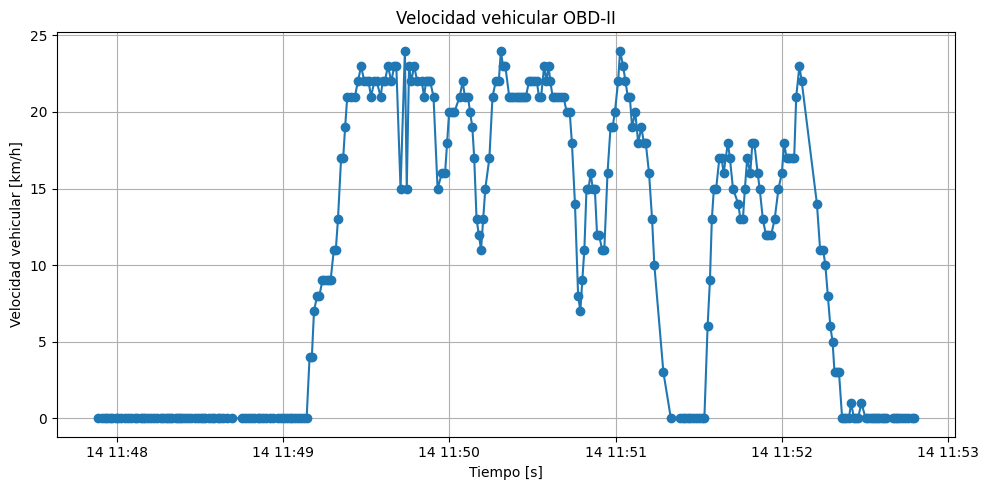

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Configuración
# =========================
input_csv = "obd_speed.csv"

time_col = "time_unix_ms"
speed_col = "Vehicle speed (km/h)"

# =========================
# Leer CSV filtrado
# =========================
df = pd.read_csv(input_csv)
df.head()
# Convertir velocidad a numérico
df[speed_col] = pd.to_numeric(df[speed_col], errors="coerce")

# Eliminar filas sin velocidad
df = df.dropna(subset=[speed_col]).reset_index(drop=True)

# =========================
# Convertir tiempo a datetime
# =========================
# Si solo tienes hora, se agrega una fecha ficticia
# fecha = "2026-05-14"
# df["timestamp"] = pd.to_datetime(fecha + " " + df[time_col])

# Tiempo relativo en segundos desde el inicio
# df["t"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

# Asegurar que timestamp sea datetime real
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Ordenar por tiempo, recomendable
df = df.sort_values("timestamp").reset_index(drop=True)

# Tiempo relativo en segundos desde el inicio
df["t"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

# Diferencial de tiempo entre muestras
df["dt"] = df["t"].diff()

# =========================
# Plot velocidad vs tiempo relativo
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df[speed_col], marker="o")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad vehicular [km/h]")
plt.title("Velocidad vehicular OBD-II")
plt.grid(True)
plt.tight_layout()
plt.show()

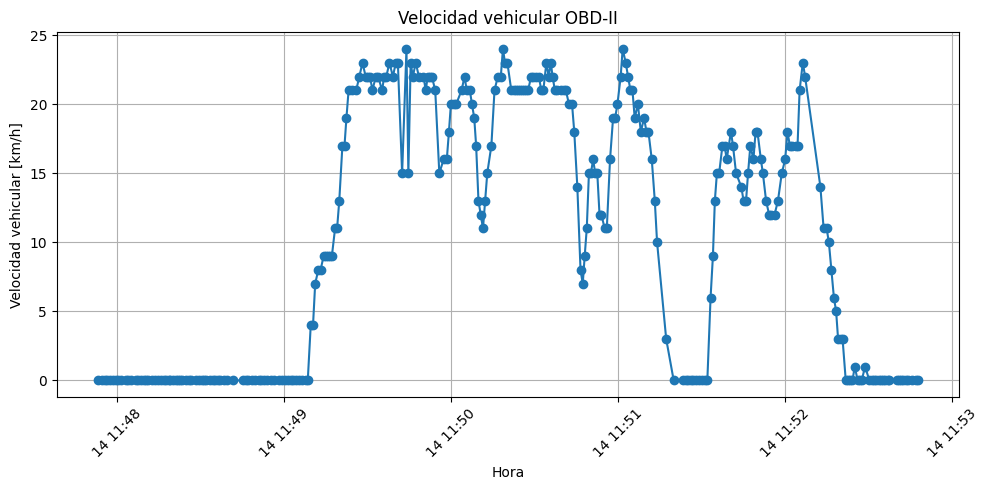

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df[speed_col], marker="o")
plt.xlabel("Hora")
plt.ylabel("Velocidad vehicular [km/h]")
plt.title("Velocidad vehicular OBD-II")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()